<a href="https://colab.research.google.com/github/Rajarajeswari77-ai/Raji/blob/main/Project_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Dataset shape:", X.shape)
print("Classes:", data.target_names)  # 0 = malignant, 1 = benign
print("Class distribution:\n", y.value_counts())

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']
Class distribution:
 target
1    357
0    212
Name: count, dtype: int64


In [2]:
# Check for missing values
print("Missing values:", X.isnull().sum().sum())

# Basic statistics
X.describe()

Missing values: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [3]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {accuracy_log:.4f}")

Logistic Regression Accuracy: 0.9825


In [5]:
dtree = DecisionTreeClassifier(random_state=42, max_depth=5)  # limit depth to avoid overfitting
dtree.fit(X_train, y_train)
y_pred_dt = dtree.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")

Decision Tree Accuracy: 0.9211


In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

Random Forest Accuracy: 0.9561


In [7]:
cv_scores_log = cross_val_score(log_reg, X_train_scaled, y_train, cv=5)
cv_scores_dt = cross_val_score(dtree, X_train, y_train, cv=5)
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=5)

print(f"LogReg CV mean: {cv_scores_log.mean():.4f} (±{cv_scores_log.std():.4f})")
print(f"Decision Tree CV mean: {cv_scores_dt.mean():.4f} (±{cv_scores_dt.std():.4f})")
print(f"Random Forest CV mean: {cv_scores_rf.mean():.4f} (±{cv_scores_rf.std():.4f})")

LogReg CV mean: 0.9802 (±0.0128)
Decision Tree CV mean: 0.9319 (±0.0213)
Random Forest CV mean: 0.9495 (±0.0256)


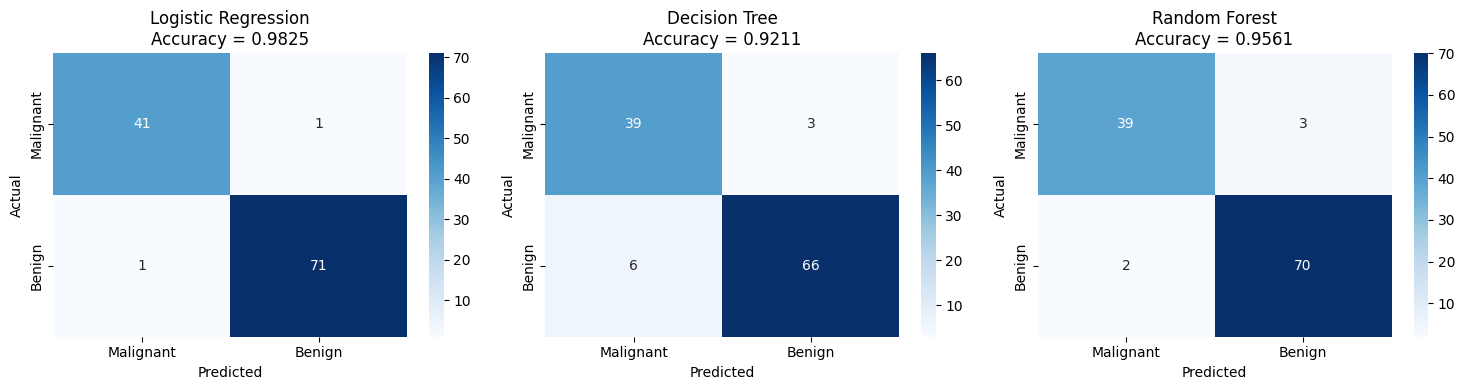

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models = [log_reg, dtree, rf]
names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
X_test_sets = [X_test_scaled, X_test, X_test]  # scaling only needed for logreg

for i, (model, name, Xt) in enumerate(zip(models, names, X_test_sets)):
    y_pred = model.predict(Xt)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'])
    axes[i].set_title(f'{name}\nAccuracy = {accuracy_score(y_test, y_pred):.4f}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300)
plt.show()

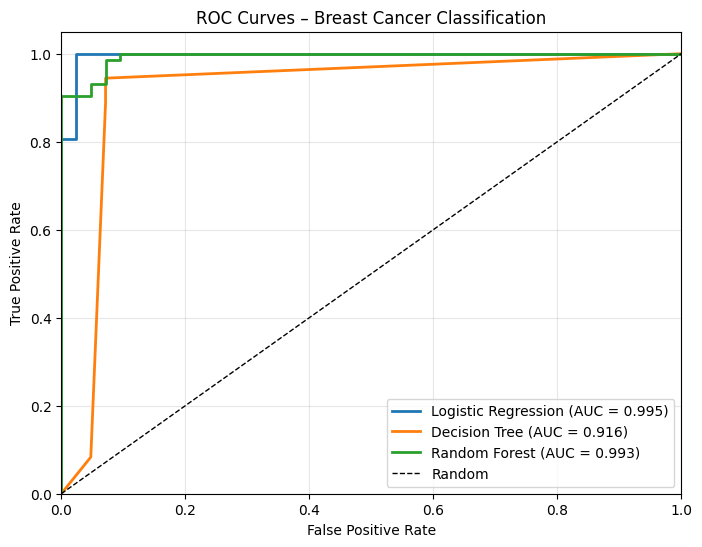

In [9]:
plt.figure(figsize=(8, 6))

for model, name, Xt in zip(models, names, X_test_sets):
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(Xt)[:, 1]  # probability of class 1 (benign)
    else:
        y_proba = model.decision_function(Xt)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – Breast Cancer Classification')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('roc_curves.png', dpi=300)
plt.show()

/tmp/ipykernel_1734/597998451.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')


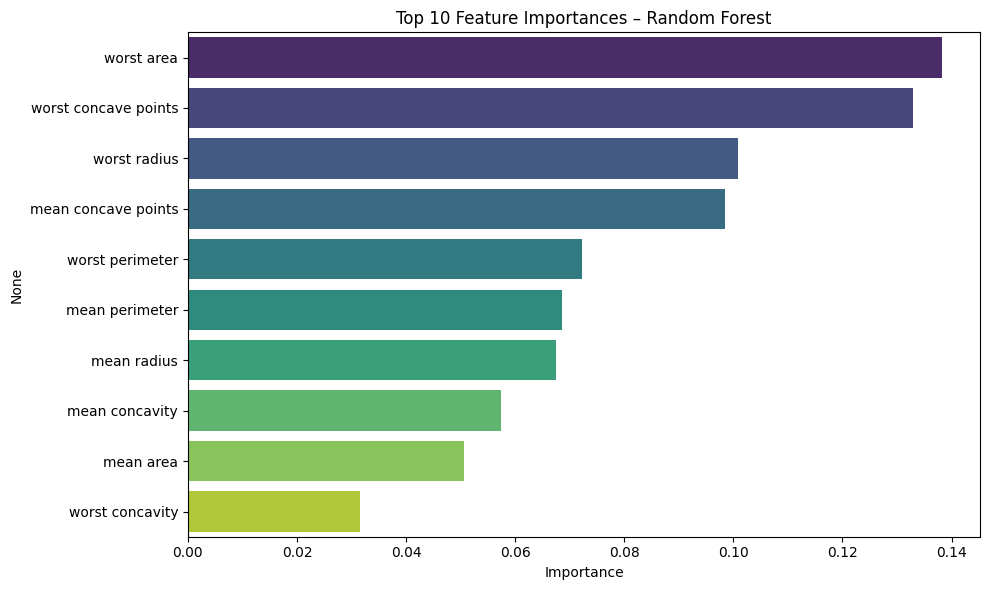

In [10]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]  # top 10 features

plt.figure(figsize=(10, 6))
plt.title('Top 10 Feature Importances – Random Forest')
sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()